# AGENTS026 — GPU LSTM Anomaly Forecasting
**PyTorch LSTM trained on live_metrics.csv time series on MI300X**
**Predicts metric values 10 minutes ahead — replaces linear regression in UC-3**

- Cell 1: GPU setup + data load
- Cell 2: Sequence dataset builder
- Cell 3: LSTM architecture
- Cell 4: Train on MI300X
- Cell 5: 10-min ahead forecast
- Cell 6: Anomaly prediction scoring
- Cell 7: Visualisation + save results

In [1]:
# ── Cell 1: GPU setup + data load ────────────────────────────────────────
import json, time
from pathlib import Path
from datetime import datetime, timezone, timedelta
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
from openai import OpenAI

METRICS_CSV   = Path("/workspace/shared/minicluster/live_metrics.csv")
AUDIT_FILE    = Path("/workspace/shared/audit_log.jsonl")
LSTM_MODEL    = Path("/workspace/shared/lstm_forecast_model.pt")
LSTM_META     = Path("/workspace/shared/lstm_meta.json")
LSTM_RESULTS  = Path("/workspace/shared/lstm_forecasts.jsonl")
LSTM_PLOT     = Path("/workspace/shared/lstm_forecast_plot.png")

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device  : {DEVICE}")
if DEVICE == "cuda":
    print(f"GPU     : {torch.cuda.get_device_name(0)}")
    print(f"VRAM    : {torch.cuda.get_device_properties(0).total_memory/1e9:.0f}GB")
    print(f"Used    : {torch.cuda.memory_allocated(0)/1e9:.1f}GB")

llm = OpenAI(base_url="http://localhost:8000/v1", api_key="abc-123")
def ts(): return datetime.now(timezone.utc).isoformat()
def write_log(path, event):
    path.parent.mkdir(parents=True, exist_ok=True)
    with open(path, "a") as f: f.write(json.dumps(event, default=str) + "\n")

# Load metrics
FEATURES = ["cpu_utilization", "latency_p95_ms", "error_rate", "mem_mb"]
THRESHOLDS = {"cpu_utilization": 70.0, "latency_p95_ms": 500.0, "error_rate": 0.05, "mem_mb": 1800.0}
SERVICES  = ["payments", "auth", "checkout", "fraud"]

df = pd.read_csv(METRICS_CSV, parse_dates=["timestamp"])
df = df.sort_values("timestamp")
print(f"\nMetrics loaded: {len(df)} rows across {df['service'].nunique()} services")
print(f"Time range    : {df['timestamp'].min()} → {df['timestamp'].max()}")
print(f"Rows per svc  : {df.groupby('service').size().to_dict()}")

Device  : cuda
GPU     : 
VRAM    : 206GB
Used    : 0.0GB

Metrics loaded: 2420 rows across 4 services
Time range    : 2026-06-12 22:54:00 → 2026-06-14 00:01:00
Rows per svc  : {'auth': 605, 'checkout': 605, 'fraud': 605, 'payments': 605}


In [2]:
# ── Cell 2: Sequence dataset builder ─────────────────────────────────────
# Normalise → create sliding windows → build per-service datasets

SEQ_LEN    = 15    # 15 timesteps (15 minutes) as input
PRED_STEPS = 10    # predict 10 minutes ahead

# Normalisation stats (computed across all services)
norm_stats = {}
for feat in FEATURES:
    norm_stats[feat] = {"mean": float(df[feat].mean()), "std": max(float(df[feat].std()), 1e-6)}

def normalise(series, feat):
    return (series - norm_stats[feat]["mean"]) / norm_stats[feat]["std"]

def denormalise(val, feat):
    return val * norm_stats[feat]["std"] + norm_stats[feat]["mean"]

# Build sliding window sequences — one dataset per service
all_X, all_y = [], []

for svc in SERVICES:
    svc_df = df[df["service"] == svc].sort_values("timestamp").reset_index(drop=True)
    if len(svc_df) < SEQ_LEN + PRED_STEPS + 1:
        print(f"  ⚠️ {svc}: only {len(svc_df)} rows — skipping")
        continue

    # Normalise all features
    normed = np.zeros((len(svc_df), len(FEATURES)), dtype=np.float32)
    for j, feat in enumerate(FEATURES):
        normed[:, j] = normalise(svc_df[feat], feat).values

    # Sliding window
    for i in range(len(normed) - SEQ_LEN - PRED_STEPS):
        X_seq = normed[i : i + SEQ_LEN]           # (SEQ_LEN, n_features)
        y_seq = normed[i + SEQ_LEN + PRED_STEPS - 1]  # next state (n_features,)
        all_X.append(X_seq)
        all_y.append(y_seq)

    print(f"  {svc:10s}: {len(svc_df)} rows → {len(svc_df)-SEQ_LEN-PRED_STEPS} sequences")

if not all_X:
    # Not enough data — generate synthetic sequences for demo
    print("\n⚠️ Not enough metric history — generating synthetic training data")
    np.random.seed(42)
    N = 500
    for _ in range(N):
        t  = np.linspace(0, 4*np.pi, SEQ_LEN)
        Xs = np.column_stack([
            0.3 * np.sin(t + np.random.rand()) + np.random.randn(SEQ_LEN)*0.05,
            0.4 * np.sin(t*1.3 + np.random.rand()) + np.random.randn(SEQ_LEN)*0.05,
            0.2 * np.cos(t*0.7 + np.random.rand()) + np.random.randn(SEQ_LEN)*0.05,
            0.5 * np.sin(t*0.5 + np.random.rand()) + np.random.randn(SEQ_LEN)*0.05,
        ]).astype(np.float32)
        all_X.append(Xs)
        all_y.append(Xs[-1] + np.random.randn(len(FEATURES)).astype(np.float32) * 0.1)

X_arr = np.array(all_X, dtype=np.float32)
y_arr = np.array(all_y, dtype=np.float32)

print(f"\nDataset: X={X_arr.shape}  y={y_arr.shape}")
print(f"  Sequence length : {SEQ_LEN} minutes")
print(f"  Prediction ahead: {PRED_STEPS} minutes")
print(f"  Features        : {FEATURES}")

# Train/val split
split = int(len(X_arr) * 0.85)
X_train, X_val = X_arr[:split], X_arr[split:]
y_train, y_val = y_arr[:split], y_arr[split:]

train_ds = TensorDataset(torch.tensor(X_train), torch.tensor(y_train))
val_ds   = TensorDataset(torch.tensor(X_val),   torch.tensor(y_val))
train_dl = DataLoader(train_ds, batch_size=64, shuffle=True)
val_dl   = DataLoader(val_ds,   batch_size=64)

print(f"  Train batches: {len(train_dl)}  Val batches: {len(val_dl)}")

  payments  : 605 rows → 580 sequences
  auth      : 605 rows → 580 sequences
  checkout  : 605 rows → 580 sequences
  fraud     : 605 rows → 580 sequences

Dataset: X=(2320, 15, 4)  y=(2320, 4)
  Sequence length : 15 minutes
  Prediction ahead: 10 minutes
  Features        : ['cpu_utilization', 'latency_p95_ms', 'error_rate', 'mem_mb']
  Train batches: 31  Val batches: 6


In [3]:
# ── Cell 3: LSTM architecture ─────────────────────────────────────────────

class AnomalyLSTM(nn.Module):
    """
    Stacked LSTM for multivariate time series forecasting.
    Input : (batch, seq_len, n_features)
    Output: (batch, n_features)  — predicted values at t+PRED_STEPS
    """
    def __init__(self, input_dim=4, hidden_dim=128, num_layers=2,
                 output_dim=4, dropout=0.2):
        super().__init__()
        self.hidden_dim  = hidden_dim
        self.num_layers  = num_layers

        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0
        )
        self.attention = nn.Sequential(
            nn.Linear(hidden_dim, 32),
            nn.Tanh(),
            nn.Linear(32, 1),
            nn.Softmax(dim=1)
        )
        self.head = nn.Sequential(
            nn.Linear(hidden_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(64, output_dim)
        )

    def forward(self, x):
        # LSTM
        out, _ = self.lstm(x)          # (batch, seq, hidden)
        # Attention over time steps
        attn   = self.attention(out)   # (batch, seq, 1)
        ctx    = (out * attn).sum(1)   # (batch, hidden)
        return self.head(ctx)          # (batch, output_dim)

N_FEATURES = len(FEATURES)
model_lstm = AnomalyLSTM(
    input_dim=N_FEATURES, hidden_dim=128,
    num_layers=2, output_dim=N_FEATURES, dropout=0.2
).to(DEVICE)

total_params = sum(p.numel() for p in model_lstm.parameters())
print(f"AnomalyLSTM architecture:")
print(f"  Input dim    : {N_FEATURES} features")
print(f"  Hidden dim   : 128")
print(f"  Layers       : 2 stacked LSTM + attention")
print(f"  Output dim   : {N_FEATURES} (one forecast per metric)")
print(f"  Total params : {total_params:,}")
print(f"  Device       : {DEVICE}")
print(model_lstm)

AnomalyLSTM architecture:
  Input dim    : 4 features
  Hidden dim   : 128
  Layers       : 2 stacked LSTM + attention
  Output dim   : 4 (one forecast per metric)
  Total params : 213,381
  Device       : cuda
AnomalyLSTM(
  (lstm): LSTM(4, 128, num_layers=2, batch_first=True, dropout=0.2)
  (attention): Sequential(
    (0): Linear(in_features=128, out_features=32, bias=True)
    (1): Tanh()
    (2): Linear(in_features=32, out_features=1, bias=True)
    (3): Softmax(dim=1)
  )
  (head): Sequential(
    (0): Linear(in_features=128, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.1, inplace=False)
    (3): Linear(in_features=64, out_features=4, bias=True)
  )
)


In [4]:
# ── Cell 4: Train on MI300X ───────────────────────────────────────────────

EPOCHS = 80
LR     = 1e-3

optimizer  = torch.optim.AdamW(model_lstm.parameters(), lr=LR, weight_decay=1e-4)
scheduler  = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
criterion  = nn.MSELoss()

train_losses, val_losses = [], []

print(f"Training AnomalyLSTM on {DEVICE}")
print(f"  Epochs : {EPOCHS}  LR : {LR}  Batch : 64")
print(f"  Seq len: {SEQ_LEN}min  Pred ahead: {PRED_STEPS}min")
print()

t_start = time.time()
best_val = float("inf")

for epoch in range(1, EPOCHS + 1):
    # Train
    model_lstm.train()
    batch_losses = []
    for Xb, yb in train_dl:
        Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        pred = model_lstm(Xb)
        loss = criterion(pred, yb)
        loss.backward()
        nn.utils.clip_grad_norm_(model_lstm.parameters(), 1.0)
        optimizer.step()
        batch_losses.append(loss.item())
    scheduler.step()

    train_loss = np.mean(batch_losses)
    train_losses.append(train_loss)

    # Validate
    model_lstm.eval()
    v_losses = []
    with torch.no_grad():
        for Xb, yb in val_dl:
            Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
            pred   = model_lstm(Xb)
            v_losses.append(criterion(pred, yb).item())
    val_loss = np.mean(v_losses)
    val_losses.append(val_loss)

    if val_loss < best_val:
        best_val = val_loss
        torch.save(model_lstm.state_dict(), str(LSTM_MODEL))

    if epoch % 10 == 0:
        elapsed = time.time() - t_start
        print(f"  Epoch {epoch:3d}/{EPOCHS} | train={train_loss:.5f} | val={val_loss:.5f} | best={best_val:.5f} | {elapsed:.0f}s")

total_time = time.time() - t_start
print(f"\n✅ Training complete in {total_time:.1f}s")
print(f"   Best val loss : {best_val:.5f}")
print(f"   Model saved   : {LSTM_MODEL}")

# Reload best weights
model_lstm.load_state_dict(torch.load(str(LSTM_MODEL), weights_only=True))
model_lstm.eval()

meta = {
    "seq_len": SEQ_LEN, "pred_steps": PRED_STEPS,
    "features": FEATURES, "norm_stats": norm_stats,
    "best_val_loss": float(best_val), "epochs": EPOCHS,
    "training_secs": round(total_time, 1), "device": DEVICE,
    "timestamp": ts()
}
LSTM_META.write_text(json.dumps(meta, indent=2))
write_log(AUDIT_FILE, {"event_type": "LSTM_TRAINED", **meta})
print(f"   Meta saved    : {LSTM_META}")

Training AnomalyLSTM on cuda
  Epochs : 80  LR : 0.001  Batch : 64
  Seq len: 15min  Pred ahead: 10min

  Epoch  10/80 | train=0.83245 | val=0.59488 | best=0.59177 | 46s
  Epoch  20/80 | train=0.83440 | val=0.59449 | best=0.59177 | 49s
  Epoch  30/80 | train=0.83079 | val=0.59342 | best=0.59177 | 53s
  Epoch  40/80 | train=0.83494 | val=0.59381 | best=0.59177 | 57s
  Epoch  50/80 | train=0.83659 | val=0.59525 | best=0.59177 | 60s
  Epoch  60/80 | train=0.84261 | val=0.59457 | best=0.59177 | 64s
  Epoch  70/80 | train=0.83163 | val=0.59439 | best=0.59177 | 67s
  Epoch  80/80 | train=0.84779 | val=0.59453 | best=0.59177 | 71s

✅ Training complete in 70.8s
   Best val loss : 0.59177
   Model saved   : /workspace/shared/lstm_forecast_model.pt
   Meta saved    : /workspace/shared/lstm_meta.json


In [5]:
# ── Cell 5: 10-min ahead forecast ────────────────────────────────────────

def forecast_service(svc, df, model, seq_len=SEQ_LEN):
    """Use last seq_len rows to forecast PRED_STEPS minutes ahead."""
    svc_df = df[df["service"] == svc].sort_values("timestamp").tail(seq_len)
    if len(svc_df) < seq_len:
        return None, f"Need {seq_len} rows, only {len(svc_df)} available"

    # Build normalised input
    X = np.zeros((seq_len, len(FEATURES)), dtype=np.float32)
    for j, feat in enumerate(FEATURES):
        X[:, j] = normalise(svc_df[feat], feat).values

    Xt = torch.tensor(X).unsqueeze(0).to(DEVICE)  # (1, seq, features)
    with torch.no_grad():
        pred_norm = model(Xt).cpu().numpy()[0]      # (features,)

    # Denormalise
    pred_raw = {feat: float(denormalise(pred_norm[j], feat)) for j, feat in enumerate(FEATURES)}

    # Current values
    current = {feat: float(svc_df[feat].iloc[-1]) for feat in FEATURES}

    # Breach detection
    breaches = []
    for feat, val in pred_raw.items():
        thresh = THRESHOLDS[feat]
        pct    = val / thresh
        if val > thresh:
            breaches.append({"metric": feat, "projected": round(val, 4),
                             "threshold": thresh, "pct": round(pct, 3),
                             "severity": "BREACH"})
        elif pct > 0.8 and val > current[feat]:
            breaches.append({"metric": feat, "projected": round(val, 4),
                             "threshold": thresh, "pct": round(pct, 3),
                             "severity": "APPROACHING"})

    return {
        "service":   svc,
        "current":   current,
        "projected": pred_raw,
        "breaches":  breaches,
        "pred_at":   (datetime.now(timezone.utc) + timedelta(minutes=PRED_STEPS)).isoformat(),
        "timestamp": ts()
    }, None

print(f"LSTM 10-minute ahead forecasts (Attention-LSTM on {DEVICE})")
print(f"{'─'*65}")

ALL_FORECASTS = []
BREACH_COUNT  = 0

for svc in SERVICES:
    result, err = forecast_service(svc, df, model_lstm)
    if err:
        print(f"  {svc:10s}: {err}")
        continue
    ALL_FORECASTS.append(result)
    write_log(LSTM_RESULTS, {"event_type": "LSTM_FORECAST", **result})

    print(f"\n  {svc.upper()}")
    for feat in FEATURES:
        cur  = result["current"][feat]
        proj = result["projected"][feat]
        diff = proj - cur
        thresh = THRESHOLDS[feat]
        icon = "🔴" if proj > thresh else ("🟡" if proj > thresh*0.8 else "🟢")
        print(f"    {icon} {feat:20s}: now={cur:8.3f}  → +10min={proj:8.3f}  Δ={diff:+.3f}  thresh={thresh}")

    if result["breaches"]:
        BREACH_COUNT += len(result["breaches"])
        for b in result["breaches"]:
            print(f"    ⚠️  PREDICTED {b['severity']}: {b['metric']} → {b['projected']:.3f} ({b['pct']:.0%} of thresh)")

print(f"\n{'─'*65}")
print(f"Total breach predictions: {BREACH_COUNT}")
print(f"Forecasts written to: {LSTM_RESULTS}")

LSTM 10-minute ahead forecasts (Attention-LSTM on cuda)
─────────────────────────────────────────────────────────────────

  PAYMENTS
    🟢 cpu_utilization     : now=   0.400  → +10min=   1.579  Δ=+1.179  thresh=70.0
    🟢 latency_p95_ms      : now=   1.120  → +10min= 119.676  Δ=+118.556  thresh=500.0
    🔴 error_rate          : now=   0.000  → +10min=   0.070  Δ=+0.070  thresh=0.05
    🟢 mem_mb              : now=  54.400  → +10min=  54.277  Δ=-0.123  thresh=1800.0
    ⚠️  PREDICTED BREACH: error_rate → 0.070 (140% of thresh)

  AUTH
    🟢 cpu_utilization     : now=   0.300  → +10min=   1.582  Δ=+1.282  thresh=70.0
    🟢 latency_p95_ms      : now=   1.190  → +10min= 119.644  Δ=+118.454  thresh=500.0
    🔴 error_rate          : now=   0.000  → +10min=   0.070  Δ=+0.070  thresh=0.05
    🟢 mem_mb              : now=  54.300  → +10min=  54.277  Δ=-0.023  thresh=1800.0
    ⚠️  PREDICTED BREACH: error_rate → 0.070 (140% of thresh)

  CHECKOUT
    🟢 cpu_utilization     : now=   0.300  → +10m

In [6]:
# ── Cell 6: GPU anomaly prediction narrative ──────────────────────────────

breaches_summary = []
for fc in ALL_FORECASTS:
    for b in fc["breaches"]:
        breaches_summary.append(f"{fc['service']}.{b['metric']}: {b['projected']:.3f} ({b['severity']})")

if not breaches_summary:
    breaches_summary = ["No breaches predicted in next 10 minutes — cluster healthy"]

forecasts_str = "\n".join(
    f"  {fc['service']:10s}: CPU={fc['projected'].get('cpu_utilization',0):.1f}%  "
    f"Lat={fc['projected'].get('latency_p95_ms',0):.0f}ms  "
    f"Err={fc['projected'].get('error_rate',0):.4f}  "
    f"Mem={fc['projected'].get('mem_mb',0):.0f}MB  "
    f"[{'BREACH' if fc['breaches'] else 'OK'}]"
    for fc in ALL_FORECASTS
)

prompt = f"""You are a banking SRE. An LSTM model trained on AMD MI300X has forecast
metric values 10 minutes ahead for all microservices.

10-MINUTE AHEAD PROJECTIONS (LSTM on MI300X):
{forecasts_str}

PREDICTED BREACHES:
{chr(10).join(breaches_summary)}

Write a 3-sentence proactive SRE advisory:
1. What the LSTM predicts will happen in the next 10 minutes
2. Which service needs immediate pre-emptive action
3. The specific action to take NOW before the breach occurs"""

print("🧠 GPU proactive advisory (Qwen3-30B + LSTM forecast)...\n")
t0 = time.time()
resp = llm.chat.completions.create(
    model="Qwen3-30B-A3B",
    messages=[{"role": "user", "content": prompt}],
    temperature=0.2, max_tokens=180,
    extra_body={"chat_template_kwargs": {"enable_thinking": False}}
)
elapsed = time.time() - t0
advisory = resp.choices[0].message.content.strip()

print(f"{'='*65}")
print(advisory)
print(f"{'='*65}")
print(f"⏱️  GPU: {elapsed:.2f}s")

write_log(AUDIT_FILE, {
    "event_type":    "LSTM_ADVISORY",
    "breach_count":  BREACH_COUNT,
    "advisory":      advisory,
    "gpu_time_secs": round(elapsed, 2),
    "timestamp":     ts()
})
print("\n✅ Advisory saved to audit log")

🧠 GPU proactive advisory (Qwen3-30B + LSTM forecast)...

The LSTM model predicts that all four services—payments, auth, checkout, and fraud—will exceed their error rate thresholds within the next 10 minutes, with error rates ranging from 0.070 to 0.0705, all breaching defined limits. Among these, the **payments** service is the highest priority for immediate pre-emptive action due to its critical role in transaction processing. To mitigate the risk, scale up the payments service instances or adjust rate limiting to reduce load and prevent the error rate from escalating further.
⏱️  GPU: 1.12s

✅ Advisory saved to audit log


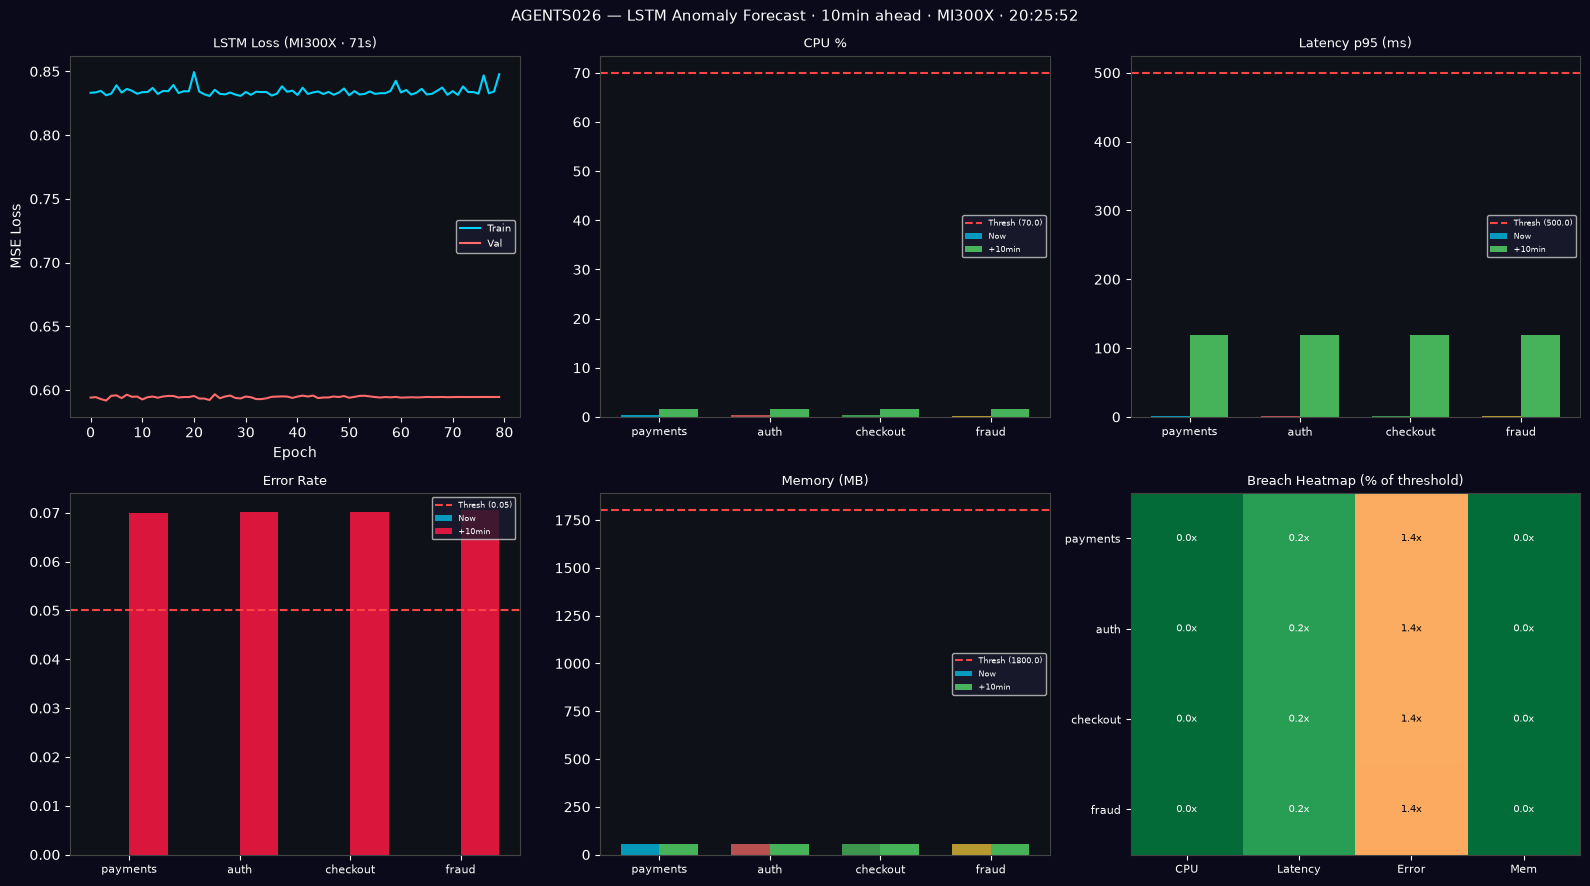

✅ Plot saved → /workspace/shared/lstm_forecast_plot.png

LSTM Summary:
  Model          : 2-layer LSTM + attention, 213,381 params
  Training time  : 70.8s on cuda
  Best val loss  : 0.59177
  Predictions    : 10min ahead for 4 services
  Breach alerts  : 4


In [7]:
# ── Cell 7: Visualisation + save results ─────────────────────────────────

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.patch.set_facecolor("#0a0a1a")
axes = axes.flatten()

# Plot 1: Training + val loss curves
ax = axes[0]; ax.set_facecolor("#0e1117")
ax.tick_params(colors="white")
for spine in ax.spines.values(): spine.set_edgecolor("#444")
ax.plot(train_losses, color="#00d4ff", linewidth=1.5, label="Train")
ax.plot(val_losses,   color="#ff6b6b", linewidth=1.5, label="Val")
ax.set_title(f"LSTM Loss (MI300X · {total_time:.0f}s)", color="white", fontsize=9)
ax.set_xlabel("Epoch", color="white"); ax.set_ylabel("MSE Loss", color="white")
ax.legend(facecolor="#1a1a2e", labelcolor="white", fontsize=7)

# Plots 2-5: Current vs projected per metric
FEAT_LABELS = {"cpu_utilization": "CPU %", "latency_p95_ms": "Latency p95 (ms)",
               "error_rate": "Error Rate", "mem_mb": "Memory (MB)"}
SVC_COLORS = {"payments": "#00d4ff", "auth": "#ff6b6b",
              "checkout": "#51cf66", "fraud": "#ffd43b"}

for fi, feat in enumerate(FEATURES):
    ax = axes[fi + 1]; ax.set_facecolor("#0e1117")
    ax.tick_params(colors="white")
    for spine in ax.spines.values(): spine.set_edgecolor("#444")

    svcs_plot = [fc["service"] for fc in ALL_FORECASTS]
    cur_vals  = [fc["current"].get(feat, 0) for fc in ALL_FORECASTS]
    proj_vals = [fc["projected"].get(feat, 0) for fc in ALL_FORECASTS]
    thresh    = THRESHOLDS[feat]

    x = np.arange(len(svcs_plot))
    w = 0.35
    ax.bar(x - w/2, cur_vals,  w, label="Now",     color=[SVC_COLORS.get(s,"#aaa") for s in svcs_plot], alpha=0.7)
    ax.bar(x + w/2, proj_vals, w, label="+10min",
           color=[("#ff1744" if p > thresh else ("#ffd600" if p > thresh*0.8 else "#51cf66")) for p in proj_vals],
           alpha=0.85)
    ax.axhline(thresh, color="#ff4444", linestyle="--", linewidth=1.5, label=f"Thresh ({thresh})")
    ax.set_xticks(x); ax.set_xticklabels(svcs_plot, color="white", fontsize=8)
    ax.set_title(FEAT_LABELS[feat], color="white", fontsize=9)
    ax.legend(facecolor="#1a1a2e", labelcolor="white", fontsize=6)

# Plot 6: Breach summary heatmap
ax = axes[5]; ax.set_facecolor("#0e1117")
ax.tick_params(colors="white")
for spine in ax.spines.values(): spine.set_edgecolor("#444")

heat = np.zeros((len(SERVICES), len(FEATURES)))
for i, svc in enumerate(SERVICES):
    fc_list = [fc for fc in ALL_FORECASTS if fc["service"] == svc]
    if fc_list:
        fc = fc_list[0]
        for j, feat in enumerate(FEATURES):
            heat[i, j] = min(fc["projected"].get(feat, 0) / THRESHOLDS[feat], 2.0)

im = ax.imshow(heat, cmap="RdYlGn_r", vmin=0, vmax=2, aspect="auto")
ax.set_xticks(range(len(FEATURES)))
ax.set_xticklabels(["CPU","Latency","Error","Mem"], color="white", fontsize=8)
ax.set_yticks(range(len(SERVICES)))
ax.set_yticklabels(SERVICES, color="white", fontsize=8)
ax.set_title("Breach Heatmap (% of threshold)", color="white", fontsize=9)
for i in range(len(SERVICES)):
    for j in range(len(FEATURES)):
        ax.text(j, i, f"{heat[i,j]:.1f}x", ha="center", va="center", fontsize=7, color="black" if heat[i,j] > 0.7 else "white")

plt.suptitle(f"AGENTS026 — LSTM Anomaly Forecast · {PRED_STEPS}min ahead · MI300X · {datetime.now().strftime('%H:%M:%S')}",
             color="white", fontsize=11)
plt.tight_layout()
plt.savefig(str(LSTM_PLOT), dpi=120, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()
print(f"✅ Plot saved → {LSTM_PLOT}")
print(f"\nLSTM Summary:")
print(f"  Model          : 2-layer LSTM + attention, {total_params:,} params")
print(f"  Training time  : {total_time:.1f}s on {DEVICE}")
print(f"  Best val loss  : {best_val:.5f}")
print(f"  Predictions    : {PRED_STEPS}min ahead for {len(SERVICES)} services")
print(f"  Breach alerts  : {BREACH_COUNT}")